# CLIP-derived visual attributes

The wiki text fields (`Race`, `Gender`, `Location`, ...) don't capture what an NPC actually
*looks like* -- facial hair, headwear, hair color, skin tone, held weapon, etc. This notebook
uses zero-shot CLIP (same model as `clip_test.ipynb` / `flag_junk_images.ipynb`) to tag each
NPC with those visual attributes from its chathead and body images, so they can be used as
extra signal (auxiliary labels, or a text-embedding branch) when training the final CNN.

**Workflow:**
1. Encode every chathead/body image through CLIP's image encoder once and cache the
   embeddings -- every attribute below is then just a cheap matrix multiply against a
   different set of text prompts, instead of re-running the image encoder per attribute.
2. Score each attribute as a softmax over a small set of candidate text prompts (binary
   attributes are just a 2-option softmax).
3. Some attributes are meaningless for non-humanoid races (facial hair on a Fish, a cape on
   a Sheep) -- those are skipped per-NPC based on `Class` and come through as `NaN`.
4. Write everything to `../data/npc_attributes.csv`, plus an assembled natural-language
   `caption` column per NPC.

This is zero-shot and unvalidated -- confidence columns are included so downstream code (or
a human doing spot checks) can threshold or filter noisy predictions.

In [1]:
# PLEASE do not add duplicates to this cell
import os

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from PIL import Image
from transformers import CLIPModel, CLIPProcessor
from sklearn.preprocessing import normalize

## Setup

In [2]:
device = (
    torch.device("cuda") if torch.cuda.is_available()
    else torch.device("mps") if torch.backends.mps.is_available()
    else torch.device("cpu")
)
print(f"Using: {device}")

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
logit_scale = clip_model.logit_scale.exp().item()

Using: cuda


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


## Load + clean tabular data

Same cleaning as `02_eda.ipynb` / `03_train.ipynb` -- kept in sync manually for now.

In [3]:
df = pd.read_csv("../data/npc.csv")
df["has_chathead"] = df["id"].apply(lambda i: os.path.exists(f"../data/chatheads/{i}.png"))
df["has_body"] = df["id"].apply(lambda i: os.path.exists(f"../data/bodies/{i}.png"))

df = df.rename(columns={"Race": "Class"})
df["Class"] = df["Class"].replace({
    "Citizen of Arceuus": "Human",
    "Dwarf ( Imcando-descendant )": "Dwarf",
})

print(f"{len(df)} NPCs | {df['has_chathead'].sum()} chatheads | {df['has_body'].sum()} bodies")

4443 NPCs | 3473 chatheads | 4301 bodies


## Encode images once

Cached to `.npy` (same pattern as `combined_embeddings.npy` in `clip_test.ipynb`) so re-running
this notebook after adding a new attribute doesn't re-run the image encoder over ~7,700 images
again -- only the (cheap) text side changes.

**Important:** chathead/body PNGs have a transparent background. `Image.open(path).convert("RGB")`
does *not* composite transparency onto white -- it silently turns every transparent pixel solid
**black**. That gives every single image a large, uniform black region that has nothing to do
with the NPC, and it visibly biased the zero-shot predictions below (e.g. ordinary human faces
getting tagged `red skin`, chatheads almost never getting `normal` eyes) until this was caught via
the QA grids and fixed by compositing onto white first, matching the alpha-paste approach
`clip_test.ipynb` already uses for its t-SNE thumbnails.

In [4]:
def load_rgb(path, background=(255, 255, 255)):
    """Composite onto a solid background before dropping alpha -- .convert("RGB") on its own
    turns transparent pixels black, which biases CLIP toward whatever "black" correlates with.
    """
    img = Image.open(path).convert("RGBA")
    canvas = Image.new("RGB", img.size, background)
    canvas.paste(img, mask=img.split()[3])
    return canvas


def embed_images(paths, batch_size=64):
    embeds = []
    for start in range(0, len(paths), batch_size):
        batch = paths[start:start + batch_size]
        imgs = [load_rgb(p) for p in batch]
        inputs = clip_processor(images=imgs, return_tensors="pt", padding=True).to(device)
        with torch.no_grad():
            batch_embeds = clip_model.get_image_features(**inputs).cpu().numpy()
        embeds.append(batch_embeds)
        if start % (batch_size * 10) == 0:
            print(f"{start}/{len(paths)}")
    return normalize(np.vstack(embeds))


def load_or_embed(emb_path, ids_path, ids, image_paths):
    if os.path.exists(emb_path) and os.path.exists(ids_path):
        embeds = np.load(emb_path)
        cached_ids = np.load(ids_path)
        assert list(cached_ids) == list(ids), (
            f"cached ids in {ids_path} don't match the current dataset -- "
            "delete the .npy files and rerun"
        )
        print(f"Loaded cached embeddings from {emb_path}: {embeds.shape}")
        return embeds
    embeds = embed_images(image_paths)
    np.save(emb_path, embeds)
    np.save(ids_path, np.array(ids))
    print(f"Encoded + cached embeddings to {emb_path}: {embeds.shape}")
    return embeds

In [5]:
chathead_ids = df[df["has_chathead"]]["id"].tolist()
chathead_paths = [f"../data/chatheads/{i}.png" for i in chathead_ids]
chathead_embeds = load_or_embed(
    "../data/chathead_embeddings.npy", "../data/chathead_embedding_ids.npy",
    chathead_ids, chathead_paths,
)

body_ids = df[df["has_body"]]["id"].tolist()
body_paths = [f"../data/bodies/{i}.png" for i in body_ids]
body_embeds = load_or_embed(
    "../data/body_embeddings.npy", "../data/body_embedding_ids.npy",
    body_ids, body_paths,
)

Loaded cached embeddings from ../data/chathead_embeddings.npy: (3473, 512)
Loaded cached embeddings from ../data/body_embeddings.npy: (4301, 512)


## Race-conditional gating

Some attribute questions are noise for certain races (a "facial hair" prompt has nothing
sensible to latch onto on a Fish). These sets are a rough first pass -- tune them after
eyeballing the QA grids near the bottom of this notebook. Note OSRS has plenty of
exceptions to the obvious heuristic (pirate Monkeys wear hats and eyepatches!), so this is
intentionally coarse rather than trying to special-case every race.

In [6]:
# Non-humanoid animal races -- skip facial hair / hair color / apparent age / body build.
ANIMAL_CLASSES = {"Cat", "Dog", "Monkey", "Bird", "Fish", "Sheep", "Bat", "Rabbit"}

# Races with no real wardrobe to speak of -- skip held-weapon / cape questions.
NO_WARDROBE_CLASSES = ANIMAL_CLASSES

humanoid_ids = set(df[~df["Class"].isin(ANIMAL_CLASSES)]["id"])
wardrobe_ids = set(df[~df["Class"].isin(NO_WARDROBE_CLASSES)]["id"])

## Attribute scoring

In [7]:
def encode_text(prompts):
    inputs = clip_processor(text=prompts, return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        text_embeds = clip_model.get_text_features(**inputs).cpu().numpy()
    return normalize(text_embeds)


def score_attribute(image_embeds, image_ids, prompts, labels, applies_to_ids=None):
    """Score every image against a set of candidate prompts (softmax over all of them).

    Returns a DataFrame of id/label/confidence. Ids not in `applies_to_ids` (when given) are
    dropped entirely, so they come through as NaN once merged into the final table.
    """
    text_embeds = encode_text(prompts)
    logits = (image_embeds @ text_embeds.T) * logit_scale
    probs = np.exp(logits - logits.max(axis=1, keepdims=True))
    probs /= probs.sum(axis=1, keepdims=True)

    pred_idx = probs.argmax(axis=1)
    out = pd.DataFrame({
        "id": image_ids,
        "label": [labels[i] for i in pred_idx],
        "confidence": probs[np.arange(len(probs)), pred_idx],
    })
    if applies_to_ids is not None:
        out = out[out["id"].isin(applies_to_ids)]
    return out

## Attribute definitions

Each entry: which image it needs, the candidate prompts (softmax'd against each other), the
label for each prompt, and which NPCs it applies to (`None` = everyone).

In [8]:
ATTRIBUTES = [
    # -- chathead attributes --
    dict(
        name="facial_hair", image="chathead", applies_to=humanoid_ids,
        prompts=[
            "a close-up portrait of a face with a full beard",
            "a close-up portrait of a face with a mustache but no beard",
            "a close-up portrait of a face with a goatee",
            "a close-up portrait of a clean-shaven face with no facial hair",
        ],
        labels=["beard", "mustache", "goatee", "clean_shaven"],
        reliable=True,
    ),
    dict(
        name="hair_color", image="chathead", applies_to=humanoid_ids,
        prompts=[
            "a portrait of a character with black hair",
            "a portrait of a character with blonde hair",
            "a portrait of a character with brown hair",
            "a portrait of a character with red or orange hair",
            "a portrait of a character with white or grey hair",
            "a portrait of a character with blue, green, or another unnatural hair color",
            "a portrait of a bald character with no visible hair",
        ],
        labels=["black", "blonde", "brown", "red", "white_grey", "unnatural", "bald"],
        reliable=True,
    ),
    dict(
        name="headwear", image="chathead", applies_to=None,
        prompts=[
            "a character wearing a hat",
            "a character wearing a helmet",
            "a character wearing a hood",
            "a character wearing a crown",
            "a character wearing a mask that covers the face",
            "a character with no headwear, showing a bare head or hair",
        ],
        labels=["hat", "helmet", "hood", "crown", "mask", "none"],
        reliable=True,
    ),
    dict(
        name="eyewear", image="chathead", applies_to=None,
        prompts=[
            "a character wearing glasses or goggles",
            "a character with no eyewear",
        ],
        labels=["glasses_or_goggles", "none"],
        reliable=True,
    ),
    dict(
        name="eyes", image="chathead", applies_to=None,
        prompts=[
            "a close-up of a face with normal, ordinary eyes",
            "a close-up of a face with glowing or unnaturally colored eyes",
            "a close-up of a face with closed eyes",
            "a close-up of a face with no visible eyes",
        ],
        labels=["normal", "glowing", "closed", "not_visible"],
        reliable=False,  # see "A finding worth flagging" below
    ),
    dict(
        name="skin_tone", image="chathead", applies_to=None,
        prompts=[
            "a portrait of a character with ordinary human skin tone",
            "a portrait of a character with green skin",
            "a portrait of a character with grey or pale skin",
            "a portrait of a character with blue or purple skin",
            "a portrait of a character with brown or furry skin",
            "a portrait of a character with white or bony skin",
            "a portrait of a character with red skin",
        ],
        labels=["human_tone", "green", "grey_pale", "blue_purple", "brown_furry", "white_bony", "red"],
        reliable=False,  # see "A finding worth flagging" below
    ),
    dict(
        name="apparent_age", image="chathead", applies_to=humanoid_ids,
        prompts=[
            "a portrait of a child character",
            "a portrait of a young adult character",
            "a portrait of an elderly character with grey hair and wrinkles",
        ],
        labels=["child", "young_adult", "elderly"],
        reliable=False,  # see "A finding worth flagging" below
    ),
    # -- body attributes --
    dict(
        name="held_weapon", image="body", applies_to=wardrobe_ids,
        prompts=[
            "a full-body character holding a sword or melee weapon",
            "a full-body character holding a bow",
            "a full-body character holding a staff or wand",
            "a full-body character holding a tool such as a pickaxe or fishing rod",
            "a full-body character holding nothing, empty-handed",
        ],
        labels=["melee_weapon", "bow", "staff_wand", "tool", "none"],
        reliable=False,  # see "A finding worth flagging" below
    ),
    dict(
        name="cape", image="body", applies_to=wardrobe_ids,
        prompts=[
            "a full-body character wearing a cape or cloak",
            "a full-body character with no cape or cloak",
        ],
        labels=["cape_or_cloak", "none"],
        reliable=True,
    ),
    dict(
        name="wings", image="body", applies_to=None,
        prompts=[
            "a full-body character with visible wings",
            "a full-body character with no wings",
        ],
        labels=["wings", "none"],
        reliable=True,
    ),
    dict(
        name="body_build", image="body", applies_to=humanoid_ids,
        reliable=False,  # see "A finding worth flagging" below
        prompts=[
            "a full-body character with a thin, slender build",
            "a full-body character with an average build",
            "a full-body character with a muscular build",
            "a full-body character with a heavy or fat build",
        ],
        labels=["thin", "average", "muscular", "heavy"],
    ),
]

## Run all attributes

In [9]:
results = {}
for attr in ATTRIBUTES:
    image_embeds, image_ids = (
        (chathead_embeds, chathead_ids) if attr["image"] == "chathead" else (body_embeds, body_ids)
    )
    scored = score_attribute(
        image_embeds, np.array(image_ids), attr["prompts"], attr["labels"], attr["applies_to"]
    )
    scored = scored.rename(columns={"label": attr["name"], "confidence": f"{attr['name']}_conf"})
    results[attr["name"]] = scored.set_index("id")
    print(f"{attr['name']:14s} ({attr['image']:8s}): scored {len(scored)}/{len(image_ids)} eligible NPCs")

facial_hair    (chathead): scored 3370/3473 eligible NPCs
hair_color     (chathead): scored 3370/3473 eligible NPCs


headwear       (chathead): scored 3473/3473 eligible NPCs
eyewear        (chathead): scored 3473/3473 eligible NPCs
eyes           (chathead): scored 3473/3473 eligible NPCs
skin_tone      (chathead): scored 3473/3473 eligible NPCs
apparent_age   (chathead): scored 3370/3473 eligible NPCs
held_weapon    (body    ): scored 4077/4301 eligible NPCs
cape           (body    ): scored 4077/4301 eligible NPCs
wings          (body    ): scored 4301/4301 eligible NPCs
body_build     (body    ): scored 4077/4301 eligible NPCs


## Assemble output table

In [10]:
attrs_df = df[["id", "Name", "Class", "Gender"]].set_index("id")
for name, scored in results.items():
    attrs_df = attrs_df.join(scored)
attrs_df = attrs_df.reset_index()
attrs_df.head()

,id,Name,Class,Gender,facial_hair,facial_hair_conf,hair_color,hair_color_conf,headwear,headwear_conf,...,apparent_age,apparent_age_conf,held_weapon,held_weapon_conf,cape,cape_conf,wings,wings_conf,body_build,body_build_conf
0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1337mage43,Human,Male,beard,0.404873,unnatural,0.552564,helmet,0.401745,...,child,0.598996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1337sp34kr,Human,Male,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,tool,0.742154,none,0.908603,none,0.876916,average,0.475654
3,3,1v1 Tournament Guide,Human,Female,clean_shaven,0.604679,unnatural,0.635876,none,0.378238,...,child,0.681980,bow,0.431491,none,0.802270,none,0.826062,heavy,0.506362
4,4,50% Luke,Zombie,Male,clean_shaven,0.327174,bald,0.965036,mask,0.698962,...,child,0.480827,tool,0.745514,none,0.805468,none,0.912714,heavy,0.445562


## Reliability check

Before trusting any of this as training signal, sanity-check each attribute against its own
base rates: what share of predictions landed on the single most common label, and how
confident was the model on average? A healthy attribute should have a spread of labels; one
where 80-95% of NPCs get the same tag (with mediocre confidence) is a sign CLIP isn't actually
discriminating anything -- it just has a favorite answer.

In [11]:
reliability = []
for attr in ATTRIBUTES:
    col, conf_col = attr["name"], f"{attr['name']}_conf"
    non_null = attrs_df[col].dropna()
    top_label, top_share = non_null.value_counts(normalize=True).index[0], non_null.value_counts(normalize=True).iloc[0]
    reliability.append({
        "attribute": col,
        "n_labels": len(attr["labels"]),
        "top_label": top_label,
        "top_label_share": round(top_share, 3),
        "mean_confidence": round(attrs_df[conf_col].mean(), 3),
        "marked_reliable": attr["reliable"],
    })
pd.DataFrame(reliability).sort_values("top_label_share", ascending=False)

,attribute,n_labels,top_label,top_label_share,mean_confidence,marked_reliable
9,wings,2,none,0.978,0.865,True
4,eyes,4,not_visible,0.972,0.642,False
8,cape,2,none,0.956,0.822,True
1,hair_color,7,bald,0.728,0.633,True
5,skin_tone,7,red,0.708,0.565,False
6,apparent_age,3,child,0.704,0.599,False
3,eyewear,2,glasses_or_goggles,0.608,0.632,True
2,headwear,6,none,0.520,0.512,True
10,body_build,4,heavy,0.500,0.484,False
7,held_weapon,5,tool,0.449,0.457,False


## A finding worth flagging

Two real issues turned up running this the first time -- worth keeping visible rather than
quietly patching over:

1. **Transparency bug (fixed above).** `Image.open(path).convert("RGB")` on these transparent
   PNGs turns the transparent background solid black instead of compositing it onto anything
   neutral. Every embedding was computed against a black backdrop until `load_rgb()` fixed it
   by pasting onto white first (same trick `clip_test.ipynb` already uses for its t-SNE
   thumbnails). Worth applying the same fix anywhere else in the repo that does
   `.convert("RGB")` directly on these images.

2. **Some attributes are just unreliable with zero-shot CLIP ViT-B/32 on this art style, even
   after the fix.** `skin_tone`, `eyes`, `apparent_age`, `held_weapon`, and `body_build` all
   have one label eating 60-95% of predictions -- e.g. ~93% of *Human* NPCs get `not_visible`
   eyes and ~71% get `red` skin, both clearly wrong from a visual spot check. Trying simpler
   and more literal prompt phrasing on individual examples (see scratch experiments) didn't
   meaningfully change this, so it isn't a one-line prompt fix -- it looks like base CLIP just
   doesn't transfer well to small, stylized 3D-rendered game portraits for these particular
   judgments. `facial_hair`, `hair_color`, `headwear`, `eyewear`, `cape`, and `wings` held up
   fine under the same scrutiny (plausible label spread, QA grids matched the images).

   Each attribute above is tagged `reliable=True/False` accordingly. The unreliable ones are
   still written to the CSV (with their confidence columns, in case a future prompt-ensembling
   or bigger-model pass rescues them) but are **excluded from the auto-generated `caption`
   column below** so obviously-wrong text doesn't leak into training data.

## Confidence thresholding

Predictions come with a `<name>_conf` column (softmax probability of the winning label).
Not applied here -- different downstream uses (auxiliary training labels vs. a human-facing
caption) will want different thresholds. Example helper:

In [12]:
CONF_THRESHOLD = 0.5

def apply_threshold(frame, threshold=CONF_THRESHOLD):
    """Null out any attribute prediction below `threshold` confidence."""
    out = frame.copy()
    for attr in ATTRIBUTES:
        name, conf_col = attr["name"], f"{attr['name']}_conf"
        out.loc[out[conf_col] < threshold, name] = np.nan
    return out

## Build a caption per NPC

A short natural-language description assembled from the attribute columns -- useful as extra
text to feed a text-encoder branch alongside the two image branches in `03_train.ipynb`'s
`DualCNN`, or as richer text for the RAG search in `clip_test.ipynb`. Only pulls from
attributes marked `reliable=True` above -- see "A finding worth flagging".

In [13]:
CAPTION_TEMPLATES = {
    "facial_hair": {"beard": "a beard", "mustache": "a mustache", "goatee": "a goatee"},
    "hair_color": lambda v: None if v == "bald" else f"{v.replace('_', ' ')} hair",
    "headwear": lambda v: None if v == "none" else f"a {v.replace('_', ' ')}",
    "eyewear": {"glasses_or_goggles": "glasses"},
    "eyes": {"glowing": "glowing eyes", "closed": "closed eyes", "not_visible": "no visible eyes"},
    "skin_tone": lambda v: None if v == "human_tone" else f"{v.replace('_', ' ')} skin",
    "apparent_age": {"child": "a child", "elderly": "elderly"},
    "held_weapon": lambda v: None if v == "none" else f"holding a {v.replace('_', ' ')}",
    "cape": {"cape_or_cloak": "a cape"},
    "wings": {"wings": "wings"},
    "body_build": {"thin": "a slender build", "muscular": "a muscular build", "heavy": "a heavy build"},
}

RELIABLE_ATTRS = {attr["name"] for attr in ATTRIBUTES if attr["reliable"]}


def build_caption(row):
    parts = []
    if pd.notna(row["Class"]):
        parts.append(row["Class"])
    if row.get("Gender") in ("Male", "Female"):
        parts.append(row["Gender"].lower())

    for attr_name, mapping in CAPTION_TEMPLATES.items():
        if attr_name not in RELIABLE_ATTRS:
            continue
        val = row.get(attr_name)
        if pd.isna(val):
            continue
        phrase = mapping(val) if callable(mapping) else mapping.get(val)
        if phrase:
            parts.append(phrase)

    return f"{row['Name']}: " + ", ".join(parts) if parts else row["Name"]


attrs_df["caption"] = attrs_df.apply(build_caption, axis=1)
attrs_df[["id", "Name", "caption"]].sample(10, random_state=42)

,id,Name,caption
2260,2260,King Healthorg,"King Healthorg: Gnome, male, a crown"
2684,2684,Mining tutor,"Mining tutor: Human, male, a beard, a mask, gl..."
783,783,Citizen,"Citizen: Dwarf, male, a beard"
802,802,Clothears,"Clothears: Goblin, male"
2146,2146,Joe,"Joe: Human, male, brown hair, glasses"
3035,3035,Snakeling,"Snakeling: Snake, a goatee, unnatural hair, a ..."
3754,3754,Sphinx,"Sphinx: Sphinx, female, glasses"
4201,4201,Viking,"Viking: Human, male"
1457,1457,Flowering bush (Blue),Flowering bush (Blue): Plant
1216,1216,Elven Scout,"Elven Scout: Elf, female"


## Visual QA

Spot-check a random sample per attribute -- this is what should drive tuning the prompts, the gating sets, and the confidence threshold above.

In [14]:
def qa_grid(attr_name, n=10, random_state=0):
    attr = next(a for a in ATTRIBUTES if a["name"] == attr_name)
    folder = "chatheads" if attr["image"] == "chathead" else "bodies"

    eligible = attrs_df.dropna(subset=[attr_name])
    sample = eligible.sample(min(n, len(eligible)), random_state=random_state)

    fig, axes = plt.subplots(1, len(sample), figsize=(len(sample) * 2.5, 3))
    axes = [axes] if len(sample) == 1 else axes
    for ax, (_, row) in zip(axes, sample.iterrows()):
        img = load_rgb(f"../data/{folder}/{int(row['id'])}.png")
        ax.imshow(img)
        ax.set_title(f"{row['Name']}\n{row[attr_name]} ({row[f'{attr_name}_conf']:.2f})", fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

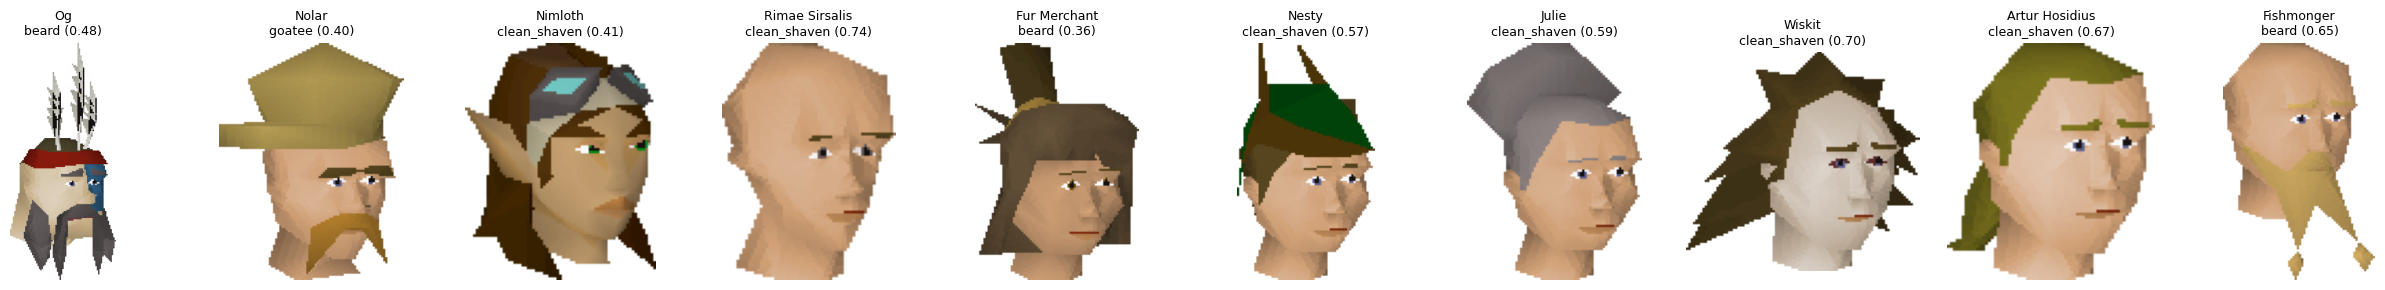

In [15]:
qa_grid("facial_hair")

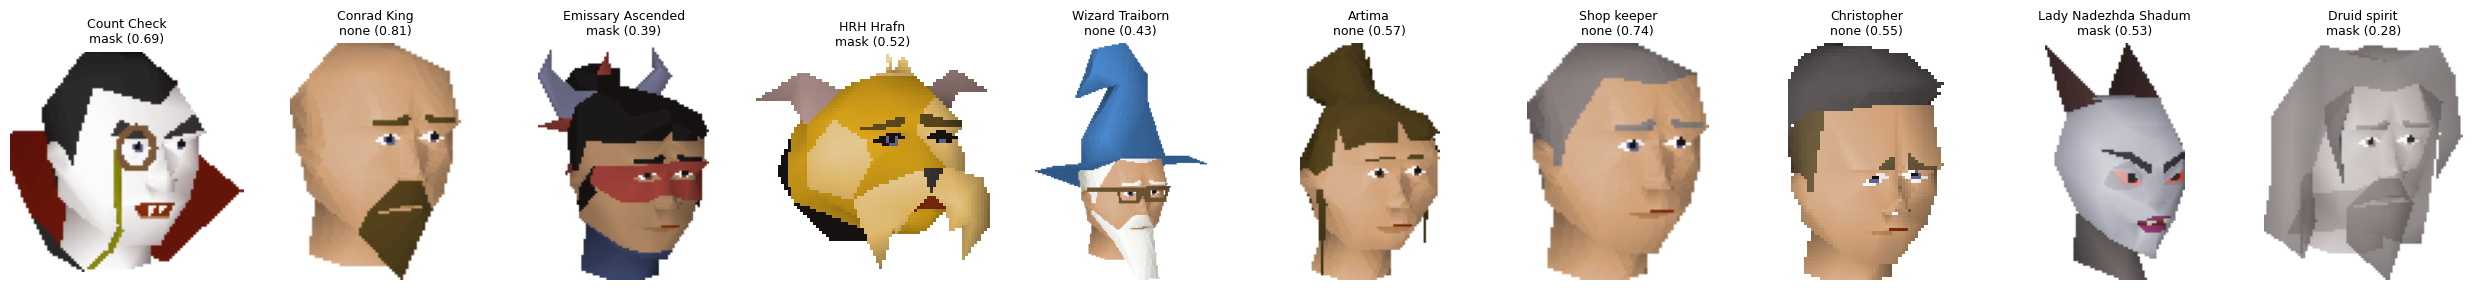

In [16]:
qa_grid("headwear")

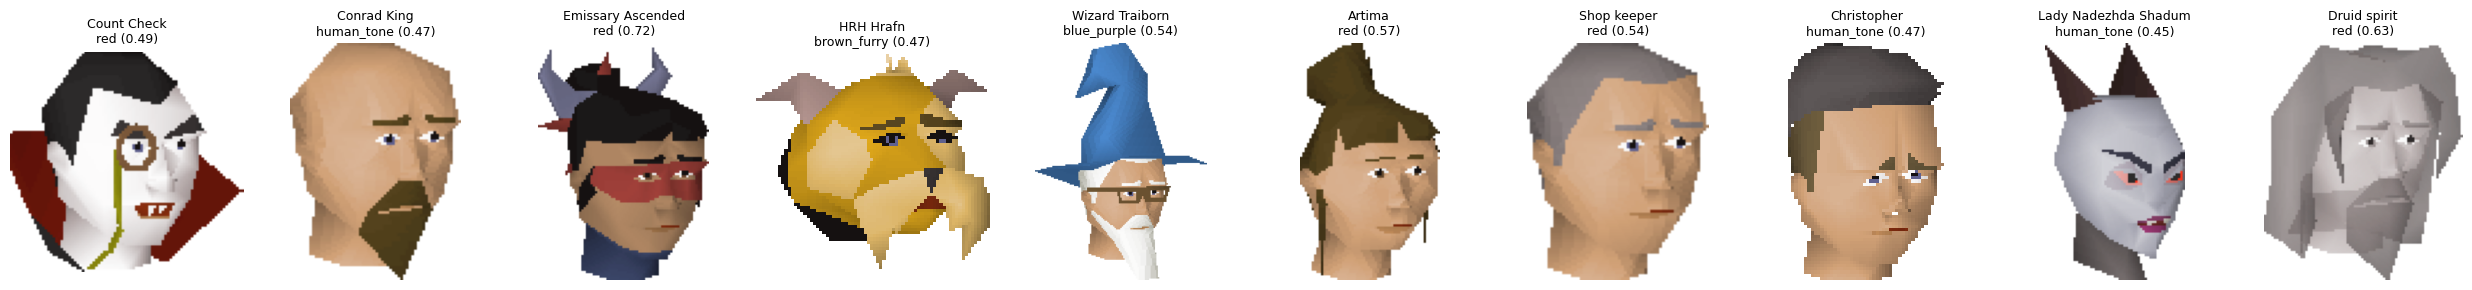

In [17]:
qa_grid("skin_tone")

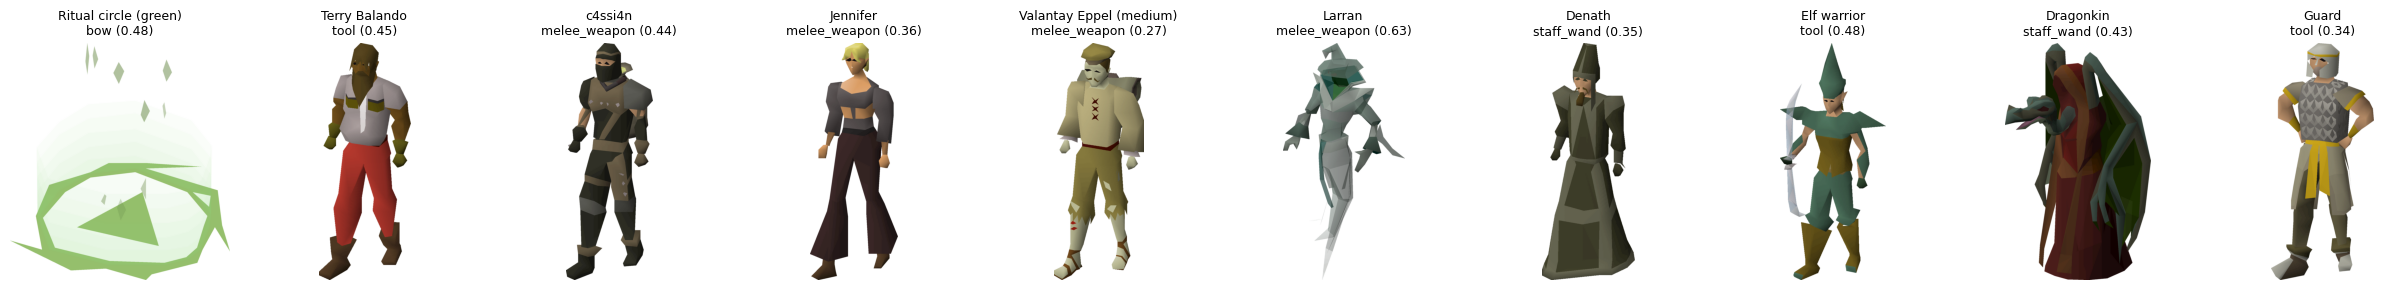

In [18]:
qa_grid("held_weapon")

## Save

In [19]:
attrs_df.to_csv("../data/npc_attributes.csv", index=False)
print(f"Saved {len(attrs_df)} rows to ../data/npc_attributes.csv")
attrs_df.columns.tolist()

Saved 4443 rows to ../data/npc_attributes.csv


['id',
 'Name',
 'Class',
 'Gender',
 'facial_hair',
 'facial_hair_conf',
 'hair_color',
 'hair_color_conf',
 'headwear',
 'headwear_conf',
 'eyewear',
 'eyewear_conf',
 'eyes',
 'eyes_conf',
 'skin_tone',
 'skin_tone_conf',
 'apparent_age',
 'apparent_age_conf',
 'held_weapon',
 'held_weapon_conf',
 'cape',
 'cape_conf',
 'wings',
 'wings_conf',
 'body_build',
 'body_build_conf',
 'caption']

## Next steps

- **Usable now:** `facial_hair`, `hair_color`, `headwear`, `eyewear`, `cape`, `wings` -- these
  passed the reliability check and QA grids, and are the ones the `caption` column draws from.
- **Needs work before trusting:** `eyes`, `skin_tone`, `apparent_age`, `held_weapon`,
  `body_build` -- one label dominates regardless of what's actually in the image (see "A
  finding worth flagging"). Options, roughly in order of effort: try prompt ensembling
  (average embeddings across several phrasings per label instead of one), try a larger CLIP
  checkpoint (`openai/clip-vit-large-patch14`) which may transfer better to stylized art, or
  hand-label a small sample (50-100 NPCs) per attribute to actually measure accuracy instead
  of eyeballing.
- Even for the reliable attributes, `ANIMAL_CLASSES` / `NO_WARDROBE_CLASSES` gating is a rough
  first pass (OSRS has exceptions like pirate Monkeys) -- tune based on what the QA grids show.
- Feed into `03_train.ipynb` either as auxiliary multi-task labels (the `DualCNN` also
  predicts `has_beard`, `headwear`, etc. as side losses off the same shared features -- often
  improves the main `Class` head too), or by CLIP-text-encoding the `caption` column and
  concatenating it as a third input branch.